In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [3]:
filename = "movies.txt"

with open(filename, "r") as fp:
  data = fp.readlines()

data

["'Breaker' Morant (1980)/Brown, Bryan (I)/Henderson, Dick (II)/Gray, Ian (I)/Woodward, Edward/Thompson, Jack (I)/Procanin, Michael/Bernard, Hank/Nicholls, Jon/Knez, Bruno/Steele, Rob (I)/Lovett, Alan/Mullinar, Rod/Ball, Ray (I)/Rodger, Ron/Mann, Trevor (I)/Smith, Chris (I)/Cisse, Halifa/Cassell, Alan (I)/Osborn, Peter/Pfitzner, John/Waters, John (III)/Tingwell, Charles 'Bud'/Kiefel, Russell/Ball, Vincent (I)/Donovan, Terence (I)/Fitz-Gerald, Lewis/Currer, Norman/Meagher, Ray/Wilson, Frank (II)/Bell, Wayne (I)/Haywood, Chris (I)/Quin, Don/Peterson, Ron/Seidel, Nellie/West, Barbara/Reed, Maria/Horseman, Sylvia/Dick, Judy/Radford, Elspeth/Walton, Laurie (I)/Cornish, Bridget/Erskine, Ria\n",
 "'burbs, The (1989)/Jayne, Billy/Howard, Rance/Ducommun, Rick/Drier, Moosie/Dern, Bruce/Kramer, Jeffrey (I)/Gordon, Gale/Theodore, Brother/Hays, Gary/Hahn, Archie/Gibson, Henry (I)/Olsen, Dana (I)/Ajaye, Franklyn/Katt, Nicky/Danziger, Cory/Hanks, Tom/Scott, Carey/Gains, Courtney/Feldman, Corey/Steven

In [4]:
title_casts = {}
for elem in data:
  elem = elem.split("/")
  title = elem[0]
  casts = elem[1:]
  casts.sort()

  title_casts[title] = casts

title_casts

{"'Breaker' Morant (1980)": ['Ball, Ray (I)',
  'Ball, Vincent (I)',
  'Bell, Wayne (I)',
  'Bernard, Hank',
  'Brown, Bryan (I)',
  'Cassell, Alan (I)',
  'Cisse, Halifa',
  'Cornish, Bridget',
  'Currer, Norman',
  'Dick, Judy',
  'Donovan, Terence (I)',
  'Erskine, Ria\n',
  'Fitz-Gerald, Lewis',
  'Gray, Ian (I)',
  'Haywood, Chris (I)',
  'Henderson, Dick (II)',
  'Horseman, Sylvia',
  'Kiefel, Russell',
  'Knez, Bruno',
  'Lovett, Alan',
  'Mann, Trevor (I)',
  'Meagher, Ray',
  'Mullinar, Rod',
  'Nicholls, Jon',
  'Osborn, Peter',
  'Peterson, Ron',
  'Pfitzner, John',
  'Procanin, Michael',
  'Quin, Don',
  'Radford, Elspeth',
  'Reed, Maria',
  'Rodger, Ron',
  'Seidel, Nellie',
  'Smith, Chris (I)',
  'Steele, Rob (I)',
  'Thompson, Jack (I)',
  "Tingwell, Charles 'Bud'",
  'Walton, Laurie (I)',
  'Waters, John (III)',
  'West, Barbara',
  'Wilson, Frank (II)',
  'Woodward, Edward'],
 "'burbs, The (1989)": ['Ajaye, Franklyn',
  'Benner, Brenda',
  'Danziger, Cory',
  'Darbo,

What does it mean for the Roman number inside the cast's name?
This is an identifier to distinguish different people with the exact same name.

In [5]:
query = "(II)"
query = "Wilson, Frank"
for key, val in title_casts.items():
  for cast in val:
    if query in cast:
      print(key)
      print("  " + cast)

'Breaker' Morant (1980)
  Wilson, Frank (II)
Awful Truth, The (1937)
  Wilson, Frank C.
Human Traffic (1999)
  Wilson, Frank (IX)


In [6]:
target_movies = {
  "Caligola",
  "Dial M for Murder",
  "The Stepford Wives",
  "To Catch a Thief", 
  "High Noon",
  "Portrait of a Lady", 
  "The Eagle Has Landed",
  "Murder on the Orient Express",
  "Cold Mountain", 
  "Footloose",
  "Whiplash",
  "Hamlet",
  "An American Haunting",
  "Animal House",
  "Apollo 13", 
  "Joe Versus the Volcano",
  "Wild Things",
  "Jude",
  "Black Mass", 
  "The Da Vinci Code",
  "Enigma",
  "Imitation Game",
  "Eternal Sunshine of the Spotless Mind",
  "Titanic"
}
target_performers = {
  "Patrick Allen",
  "Grace Kelly",
  "John Gielguld", 
  "Glenn Close",
  "Nicole Kidman",
  "Miles Teller",
  "Lloyd Bridges",
  "Donald Sutherland", 
  "Vernon Dobtcheff",
  "John Belushi",
  "Ray McKinnon",
  "Kevin Bacon",
  "Bill Paxton",
  "Tom Hanks",
  "Keira Knightley",
  "Paul Herbert",
  "Kate Winslet",
  "Benedict Cumberbatch",
  "Yves Aubert",
  "Shane Zaza",
  "Serretta Wilson"
}

In [7]:
G = nx.Graph()

for title, casts in title_casts.items():
  title = title.split(" (")[0].strip()
  if title in target_movies:
    G.add_node(title, type="title")
    for performer in casts:
       performer_clean = performer.strip()
       performer_base = performer_clean.split(" (")[0].strip()

       for target in target_performers:
        if target in performer_clean or (
            "," in performer_clean and target.split()[-1] in performer_clean):
          G.add_node(target, type="performer")
          G.add_edge(title, target)

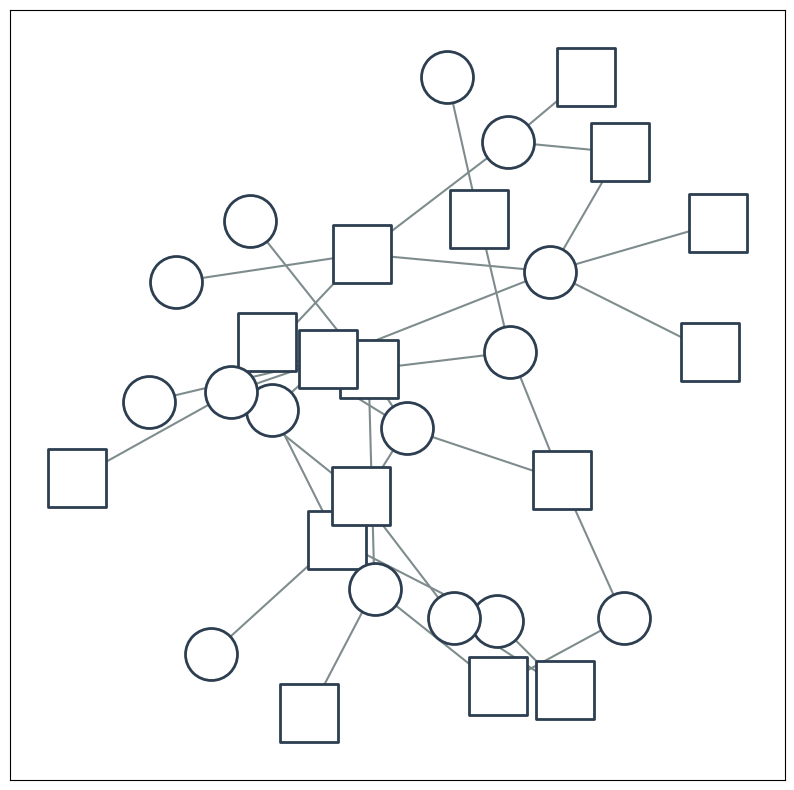

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

pos = nx.spring_layout(G, seed=42, k=0.6)
title_nodes = [n for n, attr in G.nodes(data=True)
  if attr.get("type") == "title"]
performer_nodes = [
  n for n, attr in G.nodes(data=True) if attr.get("type") == "performer" ]

nx.draw_networkx_edges(G, pos, edge_color="#7f8c8d", width=1.5, ax=ax)

nx.draw_networkx_nodes(
  G, pos, nodelist=title_nodes, node_shape="s", node_size=1800, 
  node_color="#ffffff", edgecolors="#2c3e50", linewidths=2)

nx.draw_networkx_nodes(
  G, pos, nodelist=performer_nodes, node_shape="o", node_size=1400,
  node_color="#ffffff", edgecolors="#2c3e50", linewidths=2)

plt.show(fig)

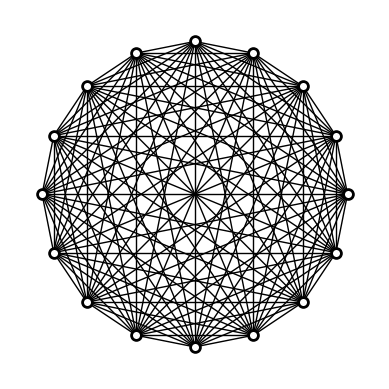

In [9]:
G = nx.complete_graph(16)

fig, ax = plt.subplots()

pos = nx.circular_layout(G)
nx.draw(G, pos, ax=ax, node_size=50, node_color="w", linewidths=2,
  edgecolors="k")

ax.set_aspect("equal")
plt.show(fig)


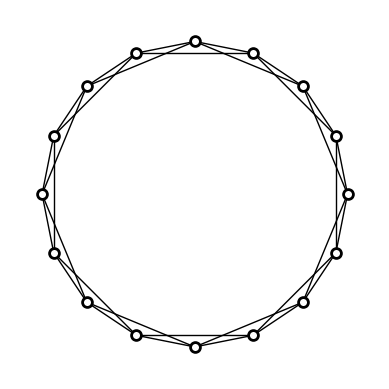

In [10]:
fig, ax = plt.subplots()

v = 16
k = 2

offsets = list(range(1, k + 1))
G = nx.circulant_graph(v, offsets)

pos = nx.circular_layout(G)

nx.draw(G, pos, ax=ax, node_size=50, node_color="w", linewidths=2,
  edgecolors="k")

ax.set_aspect("equal")
plt.show(fig)


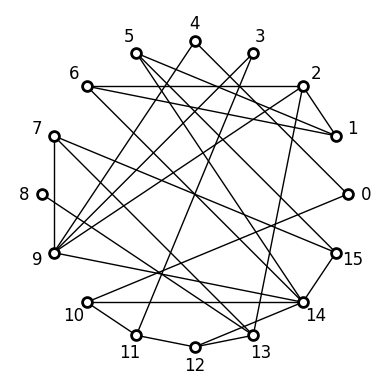

In [35]:
seed = 26_06_10

p = 0.3
G = nx.erdos_renyi_graph(16, p, seed=seed)

fig, ax = plt.subplots()

pos = nx.circular_layout(G)
nx.draw(G, pos, ax=ax, node_size=50, node_color="w", linewidths=2,
  edgecolors="k")

label_ratio = 1.12
pos_offset = {node: (coords[0] * label_ratio, coords[1] * label_ratio) 
              for node, coords in pos.items()}

nx.draw_networkx_labels(G, pos_offset)

ax.set_aspect("equal")
plt.show(fig)


In [36]:
nx.average_clustering(G)

0.09791666666666665

In [40]:
vertex_set = []
degree_set = []
for k, v in G.degree:
  vertex_set.append(k)
  degree_set.append(v)

vertex_set = np.array(vertex_set)
degree_set = np.array(degree_set)

df_clustering_coeff = pd.DataFrame()
df_clustering_coeff["vertex"] = vertex_set
df_clustering_coeff["degree"] = degree_set
df_clustering_coeff["possible"] = (degree_set * (degree_set - 1)/2).astype(int)

# calculate the number of actual edges in the neighbors of a given vertex
actual_edges = np.zeros(len(vertex_set)) 
for idx, node in enumerate(vertex_set):
  neighbors = list(G.neighbors(node))
  # print(neighbors)
  num_of_neighbors = len(neighbors)
  actual_edges[idx] = 0
  for i in range(num_of_neighbors-1):
    for j in range(i+1, num_of_neighbors):
      u = neighbors[i]
      v = neighbors[j]
      if G.has_edge(u, v):
        actual_edges[idx] += 1

df_clustering_coeff["actual"] = actual_edges.astype(int)

df_clustering_coeff

,vertex,degree,possible,actual
0,0,2,1,0
1,1,3,3,1
2,2,4,6,1
3,3,2,1,0
4,4,2,1,0
5,5,3,3,1
6,6,3,3,1
7,7,3,3,0
8,8,1,0,0
9,9,5,10,0


In [42]:
clustering_coeff = (df_clustering_coeff["actual"]/df_clustering_coeff["possible"]).sum()/len(vertex_set)
clustering_coeff

np.float64(0.09791666666666667)